  Activating project at `/opt/anaconda3/envs/py_juliacall/julia_env`
   Resolving package versions...
    Updating `/opt/anaconda3/envs/py_juliacall/julia_env/Project.toml`
  [525bcba6] + FITSIO v0.17.5
    Updating `/opt/anaconda3/envs/py_juliacall/julia_env/Manifest.toml`
  [3b1b4be9] + CFITSIO v1.7.2
  [525bcba6] + FITSIO v0.17.5
  [6e34b625] + Bzip2_jll v1.0.9+0
  [b3e40c51] + CFITSIO_jll v4.7.0+0
Precompiling packages...
   0.6 s  ✓ Bzip2_jll
   1.0 s  ✓ CFITSIO_jll
   0.8 s  ✓ CFITSIO
   0.8 s  ✓ FITSIO
  4 dependencies successfully precompiled in 4 seconds. 20 already precompiled.


Installing FITSIO.jl into JuliaCall environment...
Using existing FITS file: HorseHead.fits
Number of HDUs: 2

FITS Header:
SIMPLE: True
BITPIX: 16
NAXIS: 2
NAXIS1: 891
NAXIS2: 893
EXTEND: True
DATE: 2014-01-09
ORIGIN: STScI/MAST
SURVEY: SERC-ER
REGION: ER768
PLATEID: A0JP
SCANNUM: 01
DSCNDNUM: 00
TELESCID: 4
BANDPASS: 36
COPYRGHT: AAO/ROE
SITELAT: -31.277
SITELONG: 210.934
TELESCOP: UK Schmidt - Doubl
INSTRUME: Photographic Plate
EMULSION: IIIaF
FILTER: OG590
PLTSCALE: 67.2
PLTSIZEX: 355.0
PLTSIZEY: 355.0
PLATERA: 85.599455
PLATEDEC: -4.9466091
PLTLABEL: OR14052
DATE-OBS: 1990-12-22T13:49:00
EXPOSURE: 65.0
PLTGRADE: AD2
OBSHA: 0.158333
OBSZD: 26.3715
AIRMASS: 1.11587
REFBETA: 66.319642
REFBETAP: -0.082
REFK1: 6423.5229
REFK2: -102122.55
CNPIX1: 12237
CNPIX2: 19965
XPIXELS: 23040
YPIXELS: 23040
XPIXELSZ: 15.0295
YPIXELSZ: 15.0
PPO1: -3069417.0
PPO2: 0.0
PPO3: 177500.0
PPO4: 0.0
PPO5: 3069417.0
PPO6: 177500.0
PLTRAH: 5
PLTRAM: 42
PLTRAS: 23.86
PLTDECSN: -
PLTDECD: 4
PLTDECM: 56
PLTDECS:

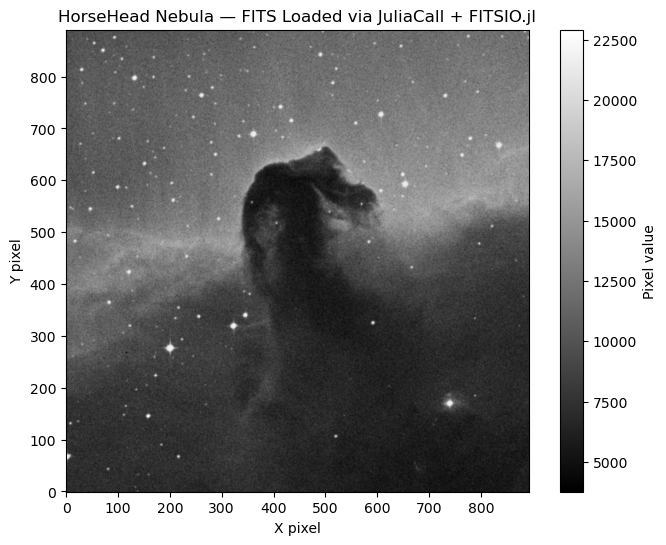

In [3]:
"""
fits_reader.py

A fully self-contained example showing how to use JuliaCall inside Python
to download, read, inspect, and visualize FITS files using Julia's FITSIO.jl.

This module demonstrates the correct hybrid workflow:
- Python handles downloading, visualization, and astronomy ecosystem tools.
- Julia handles fast, memory-efficient FITS I/O via FITSIO.jl.
- JuliaCall bridges both worlds cleanly.

NOTE: This uses FITSIO.jl (a wrapper around cfitsio), which is the
standard, actively maintained package for FITS I/O in Julia. An earlier
version of this script referenced a package called "FITSFiles.jl" whose
`open()` call was silently falling through to Julia's built-in `Base.open`,
returning a generic IOStream instead of a FITS object -- hence the
`MethodError: no method matching length(::IOStream)` you may have seen.
"""

from juliacall import Main as jl
import numpy as np
import matplotlib.pyplot as plt
import requests
import os


# ---------------------------------------------------------------------------
# STEP 1 — Ensure FITSIO.jl is installed in JuliaCall's environment
# ---------------------------------------------------------------------------
jl.seval("""
import Pkg
Pkg.activate("/opt/anaconda3/envs/py_juliacall/julia_env")

if !("FITSIO" in keys(Pkg.project().dependencies))
    println("Installing FITSIO.jl into JuliaCall environment...")
    Pkg.add("FITSIO")
    Pkg.precompile()
else
    println("FITSIO.jl already installed.")
end
""")


# ---------------------------------------------------------------------------
# STEP 2 — Load FITSIO.jl
# ---------------------------------------------------------------------------
jl.seval("using FITSIO")


# ---------------------------------------------------------------------------
# STEP 3 — Download a guaranteed-valid FITS file
# ---------------------------------------------------------------------------
fits_url = "https://astropy.stsci.edu/data/tutorials/FITS-images/HorseHead.fits"
local_filename = "HorseHead.fits"

if not os.path.exists(local_filename):
    print(f"Downloading FITS file from {fits_url} ...")
    response = requests.get(fits_url)
    response.raise_for_status()
    with open(local_filename, "wb") as f:
        f.write(response.content)
    print(f"Saved FITS file to {local_filename}")
else:
    print(f"Using existing FITS file: {local_filename}")

jl.fname = local_filename  # Register filename in Julia


# ---------------------------------------------------------------------------
# STEP 4 — Open the FITS file in Julia (FITSIO.FITS, not FITSFiles.open)
# ---------------------------------------------------------------------------
fits_obj = jl.seval("FITS(fname)")
jl.fits_obj = fits_obj  # REQUIRED


# ---------------------------------------------------------------------------
# STEP 5 — Inspect HDUs safely
# ---------------------------------------------------------------------------
num_hdus = jl.seval("length(fits_obj)")
print(f"Number of HDUs: {num_hdus}")

if num_hdus < 1:
    jl.seval("close(fits_obj)")
    raise RuntimeError("FITS file contains no HDUs with data.")


# ---------------------------------------------------------------------------
# STEP 6 — Extract first HDU data
#
# FITSIO uses read(hdu), not a .data field.
# ---------------------------------------------------------------------------
data = jl.seval("read(fits_obj[1])")
data_np = np.array(data)


# ---------------------------------------------------------------------------
# STEP 7 — Extract header metadata
#
# FITSIO uses read_header(hdu), not a .header field, and the resulting
# Header object isn't directly dict()-able from Python -- pull the keys
# in Julia, then build the Python dict.
# ---------------------------------------------------------------------------
jl.seval("header = read_header(fits_obj[1])")
header_keys = jl.seval("collect(keys(header))")

header_py = {}
for k in header_keys:
    key_str = str(k)
    jl.hkey = key_str
    header_py[key_str] = jl.seval("header[hkey]")


# ---------------------------------------------------------------------------
# STEP 8 — Print header keys and values
# ---------------------------------------------------------------------------
print("\nFITS Header:")
for k, v in header_py.items():
    print(f"{k}: {v}")


# ---------------------------------------------------------------------------
# STEP 9 — Close the FITS file
#
# FITSIO keeps the underlying cfitsio file pointer open until closed.
# ---------------------------------------------------------------------------
jl.seval("close(fits_obj)")


# ---------------------------------------------------------------------------
# STEP 10 — Plot the FITS image using Python
# ---------------------------------------------------------------------------
plt.figure(figsize=(8, 6))
plt.imshow(data_np, cmap="gray", origin="lower")
plt.colorbar(label="Pixel value")
plt.title("HorseHead Nebula — FITS Loaded via JuliaCall + FITSIO.jl")
plt.xlabel("X pixel")
plt.ylabel("Y pixel")
plt.show()